In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix

# Helper Function

In [2]:
emoji_map = {
    0: ":heart:",
    1: ":baseball:",
    2: ":smile:",
    3: ":disappointed:",
    4: ":fork_and_knife:"
}

In [3]:
def label_to_emoji(label: int, emoji_map: dict):
    val = emoji_map[label]
    if val.startswith(":") and val.endswith(":"):
        return emoji.emojize(val, language='alias')
    else:
        return val

In [4]:
for i in emoji_map.keys():
    e = label_to_emoji(i, emoji_map)
    print(e)

❤️
⚾
😄
😞
🍴


# Data

In [5]:
train_data = pd.read_csv("data/train_emoji.csv", header=None)
train_data = train_data.loc[:, [0, 1]]
train_data.columns = ["phrase", "emoji"]
train_data.head()

,phrase,emoji
0,never talk to me again,3
1,I am proud of your achievements,2
2,It is the worst day in my life,3
3,Miss you so much,0
4,food is life,4


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   phrase  132 non-null    object
 1   emoji   132 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [7]:
train_data.emoji.value_counts()

emoji
2    38
3    36
0    22
1    19
4    17
Name: count, dtype: int64

In [8]:
test_data = pd.read_csv("data/test_emoji.csv", header=None)
test_data[0] = test_data[0].str.strip()
test_data.columns = ["phrase", "emoji"]
test_data.head()

,phrase,emoji
0,I want to eat,4
1,he did not answer,3
2,he got a very nice raise,2
3,she got me a nice present,2
4,ha ha ha it was so funny,2


In [9]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   phrase  56 non-null     object
 1   emoji   56 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ KB


In [10]:
X_train = train_data.phrase.values
y_train = train_data.emoji.values
y_train_oh = to_categorical(y_train, num_classes=None)  # None to automatically detect

X_test = test_data.phrase.values
y_test = test_data.emoji.values
y_test_oh = to_categorical(y_test, num_classes=None)  # None to automatically detect

In [11]:
for idx in range(10):
    print(X_train[idx], label_to_emoji(y_train[idx], emoji_map))

never talk to me again 😞
I am proud of your achievements 😄
It is the worst day in my life 😞
Miss you so much ❤️
food is life 🍴
I love you mum ❤️
Stop saying bullshit 😞
congratulations on your acceptance 😄
The assignment is too long  😞
I want to go play ⚾


In [12]:
y_train.shape, y_train_oh.shape

((132,), (132, 5))

In [13]:
y_train[0], y_train_oh[0]

(3, array([0., 0., 0., 1., 0.]))

# GloVe for Classification Task

### Embedding for Word

In [14]:
GLOVE_FILE = "model/glove.6B.50d.txt/glove.6B.50d.txt"

In [15]:
def read_GloVe_txt(file):
    with open(file, 'r', encoding='utf-8') as f:
        words = set()
        word2vec = {}
        for line in f:
            list = line.strip().split()
            word = list[0]
            vector = np.array(list[1:], dtype=np.float64)
            words.add(word)
            word2vec[word] = vector
    return words, word2vec

In [16]:
words, word2vec = read_GloVe_txt(GLOVE_FILE)

print("Number of words for embedding in GloVe:", len(words))
print("Embedding size of a word in GloVe:", word2vec['the'].shape)

Number of words for embedding in GloVe: 400000
Embedding size of a word in GloVe: (50,)


### Embedding for Sequence

In [17]:
def get_sequence_vector(sequence, word2vec):
    words = sequence.lower().split()
    
    any_word = next(iter(word2vec))
    seq_vec = np.zeros(word2vec[any_word].shape)
    
    count = 0
    for w in words:
        if w in word2vec:
            seq_vec += word2vec[w]
            count += 1

    if count > 0:
        seq_vec /= count

    return seq_vec

In [18]:
idx = 0
seq = X_train[idx]
seq_vec = get_sequence_vector(seq, word2vec)

print(seq)
print(seq_vec.shape)
print(seq_vec)

never talk to me again
(50,)
[ 9.718460e-02  1.743740e-02  5.284300e-02 -4.368060e-01  2.756132e-01
 -1.426688e-01 -6.120520e-01  4.716140e-01 -6.059740e-01  1.566594e-01
 -8.662400e-02  4.906620e-01 -6.480320e-01 -1.612960e-01  8.897200e-01
  4.867520e-01  4.601260e-02 -8.363342e-02 -2.288840e-01 -4.151500e-01
 -1.140000e-02  6.407600e-01  5.954280e-01  1.780868e-01  7.128668e-01
 -2.072760e+00 -3.161338e-01  1.869920e-01  6.583040e-01 -6.969300e-01
  3.172380e+00  5.411100e-01 -5.941440e-01 -3.028740e-01 -2.285386e-01
 -2.899120e-01  2.006040e-01  1.053064e-01 -3.933000e-02 -4.483020e-01
 -1.353596e-01 -2.031200e-03 -2.454976e-01  1.305460e-01 -1.976000e-02
  2.025340e-02 -1.199070e-01 -2.522034e-01 -2.197784e-01  3.076060e-01]


### Classification Model based on GloVe

In [19]:
def softmax(x, axis=None):
    x_shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x_shifted)
    s = exp_x / np.sum(exp_x, axis=axis, keepdims=True)
    return s

In [20]:
def predict(sequences, word2vec, parameters):
    W, b = parameters['W'], parameters['b']

    # if only 1 sentence
    if isinstance(sequences, str):
        sequences = [sequences]
        
    # Get embedding vector for sequences
    seq_vecs = []
    for seq in sequences:
        seq_vecs.append(get_sequence_vector(seq, word2vec))
    seq_vecs = np.vstack(seq_vecs)  # shape (n_sentences, embedding_size)

    # Predict
    z = np.dot(W, seq_vecs.T) + b.reshape(-1, 1)  # shape (n_classes, n_sentences)
    y_pred = softmax(z.T, axis=1)  # z.T shape (n_sentences, n_classes)
    labels_pred = np.argmax(y_pred, axis=1)  # shape (n_sentences, )
    
    return labels_pred

In [21]:
def compute_val_accuracy(X_val, y_val_onehot, word2vec, parameters):
    pred_labels = predict(X_val, word2vec, parameters) 
    true_labels = np.argmax(y_val_onehot, axis=1)
    accuracy = np.mean(pred_labels == true_labels)
    return accuracy

In [22]:
def train_GloVe_for_classification(X_train, y_train_onehot, X_val, y_val_onehot,word2vec, epochs=50, learning_rate=0.001):    
    n_sequences, n_classes = y_train_onehot.shape
    
    any_word = next(iter(word2vec))
    embedding_size = word2vec[any_word].shape[0]
    
    # Init parameters
    W = np.random.randn(n_classes, embedding_size) / np.sqrt(embedding_size)
    b = np.zeros((n_classes))

    # Metrics
    losses = []
    train_accuracies = []
    val_accuracies = []
    
    for e in range(epochs):
        epoch_loss = 0
        corrected_pred = 0
        
        # Stochastic Gradient Descent
        for i in range(n_sequences):
            seq = X_train[i]
            seq_vec = get_sequence_vector(seq, word2vec)  # shape of (embedding_size, )
            
            # Forward
            z = np.dot(W, seq_vec) + b
            y_pred = softmax(z)
            
            # Loss
            label = y_train_onehot[i]  # shape of (n_classes, )
            loss = -np.sum(label * np.log(y_pred))
            epoch_loss += loss

            # Accuracy
            if np.argmax(y_pred) == np.argmax(label):
                corrected_pred += 1
            
            # Backward
            dz = y_pred - label
            dW = np.dot(dz.reshape(n_classes, 1), seq_vec.reshape(1, embedding_size))
            db = dz

            # Update parameters
            W = W - learning_rate * dW
            b = b - learning_rate * db
        
        # Compute metrics for each epoch
        epoch_loss = epoch_loss / n_sequences
        train_acc = corrected_pred / n_sequences
        val_acc = compute_val_accuracy(X_val, y_val_onehot, word2vec, {'W': W, 'b': b})
        
        losses.append(epoch_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if e % 10 == 0 or e == epochs - 1:
            print(f"Epoch {e+1:03d}/{epochs} - Loss: {epoch_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

    parameters = {'W': W, 'b': b}
    return losses, train_accuracies, val_accuracies, parameters

In [23]:
losses, train_accuracies, val_accuracies, parameters = train_GloVe_for_classification(
    X_train, y_train_oh, X_test, y_test_oh, word2vec, epochs=300, learning_rate=0.01
)

Epoch 001/300 - Loss: 1.6497 - Train Acc: 0.2500 - Val Acc: 0.3214
Epoch 011/300 - Loss: 0.9560 - Train Acc: 0.7424 - Val Acc: 0.6964
Epoch 021/300 - Loss: 0.7536 - Train Acc: 0.7803 - Val Acc: 0.7857
Epoch 031/300 - Loss: 0.6483 - Train Acc: 0.7955 - Val Acc: 0.8036
Epoch 041/300 - Loss: 0.5797 - Train Acc: 0.8409 - Val Acc: 0.7857
Epoch 051/300 - Loss: 0.5299 - Train Acc: 0.8561 - Val Acc: 0.8036
Epoch 061/300 - Loss: 0.4913 - Train Acc: 0.8712 - Val Acc: 0.8036
Epoch 071/300 - Loss: 0.4602 - Train Acc: 0.8864 - Val Acc: 0.8036
Epoch 081/300 - Loss: 0.4344 - Train Acc: 0.9015 - Val Acc: 0.8214
Epoch 091/300 - Loss: 0.4125 - Train Acc: 0.9015 - Val Acc: 0.8214
Epoch 101/300 - Loss: 0.3937 - Train Acc: 0.9242 - Val Acc: 0.8214
Epoch 111/300 - Loss: 0.3773 - Train Acc: 0.9242 - Val Acc: 0.8214
Epoch 121/300 - Loss: 0.3628 - Train Acc: 0.9242 - Val Acc: 0.8214
Epoch 131/300 - Loss: 0.3499 - Train Acc: 0.9318 - Val Acc: 0.8214
Epoch 141/300 - Loss: 0.3383 - Train Acc: 0.9394 - Val Acc: 0.

In [24]:
def plot_metrics(losses, train_accuracies, val_accuracies):
    epochs = range(1, len(losses) + 1)

    plt.figure(figsize=(16, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, losses, label='Loss', linewidth=2)
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Train Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy', color='green', linewidth=2)
    plt.title('Training Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()

    # Validation Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='orange', linewidth=2)
    plt.title('Validation Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

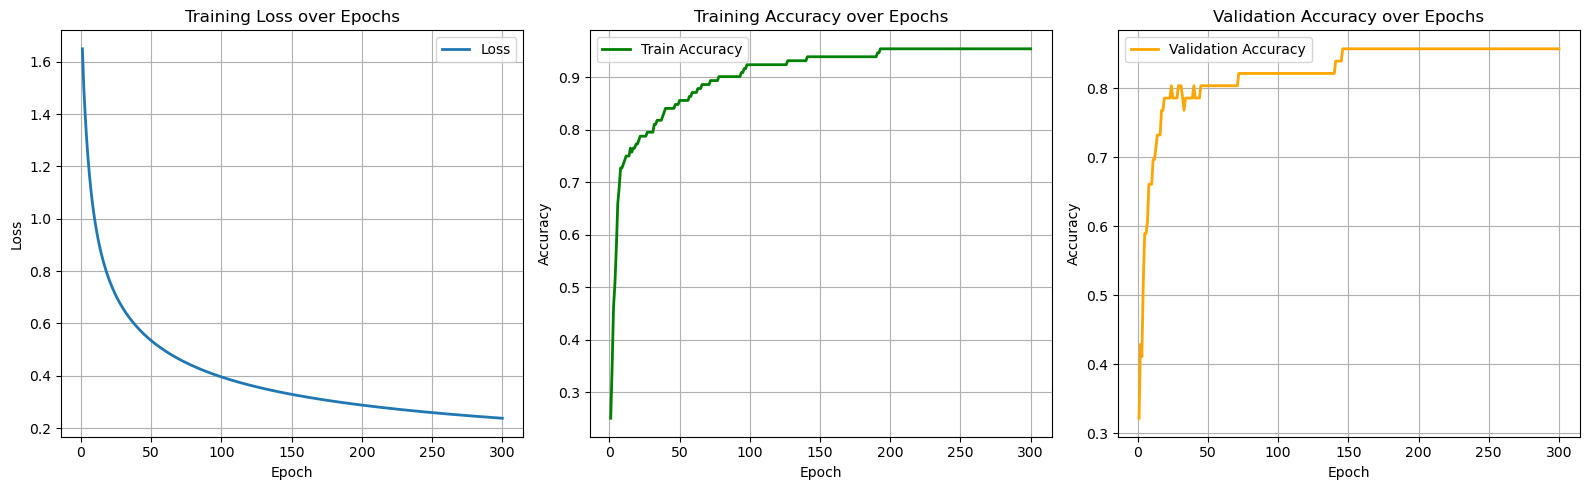

In [25]:
plot_metrics(losses, train_accuracies, val_accuracies)

In [26]:
def plot_confusion_matrix(y_true, y_pred, emoji_map, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    emoji_classes = [emoji.emojize(emoji_map[i], language='alias') for i in range(len(emoji_map))]

    plt.rcParams['font.family'] = 'Segoe UI Emoji'  # to show emoji
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=emoji_classes, yticklabels=emoji_classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

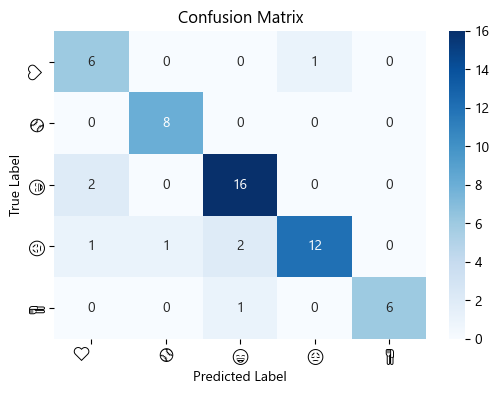

In [27]:
y_test_pred = predict(X_test, word2vec, parameters)

plot_confusion_matrix(y_test, y_test_pred, emoji_map)

In [28]:
examples_Y = np.array([[0], [0], [2], [1], [4], [3]])
examples_X = np.array([
    "i adore you", 
    "i love you", 
    "funny lol", 
    "lets play with a ball", 
    "food is ready", 
    "not feeling happy"
])

examples_pred = predict(examples_X, word2vec, parameters)
examples_pred

array([0, 0, 2, 1, 4, 2], dtype=int64)

In [29]:
def print_seq_with_emoji(sequences, labels, emoji_map):
    for i in range(len(sequences)):
        label = int(labels[i])
        e = label_to_emoji(label, emoji_map)
        print(f"{sequences[i]} - {e}")

In [30]:
print_seq_with_emoji(examples_X, examples_pred, emoji_map)
print()
print_seq_with_emoji(examples_X, examples_Y.ravel(), emoji_map)

i adore you - ❤️
i love you - ❤️
funny lol - 😄
lets play with a ball - ⚾
food is ready - 🍴
not feeling happy - 😄

i adore you - ❤️
i love you - ❤️
funny lol - 😄
lets play with a ball - ⚾
food is ready - 🍴
not feeling happy - 😞


# LSTM for Classification Task

In [31]:
import tensorflow
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Activation, Dropout, LSTM, Embedding
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [32]:
def get_word_indices(words):
    word_to_idx = {}
    idx_to_word = {}

    # index 0 is for <PAD> token
    idx = 1
    for w in sorted(words):
        word_to_idx[w] = idx
        idx_to_word[idx] = w
        idx += 1

    return word_to_idx, idx_to_word

In [33]:
word_to_idx, idx_to_word = get_word_indices(words)

In [34]:
word = "cucumber"
idx = 289846
print("the index of", word, "in the vocabulary is", word_to_idx[word])
print("the", str(idx) + "th word in the vocabulary is", idx_to_word[idx])

the index of cucumber in the vocabulary is 113317
the 289846th word in the vocabulary is potatos


### Convert a Sequence to List of Indices with Padding

In [35]:
def convert_seq_to_indices(sequences, word_to_idx, maxSeqLen):
    n_sequences = sequences.shape[0]  # shape of sequences (n_sequences, )
    
    indices = np.zeros((n_sequences, maxSeqLen))
    
    for i in range(n_sequences):
        words = sequences[i].lower().split()
        position = 0
        for w in words:
            if w in word_to_idx:  
                indices[i, position] = word_to_idx[w]
            else:
                indices[i, position] = word_to_idx["<UNK>"]  # still do it, although <UNK> not exists in GloVe
            position += 1
                
    return indices

### Pretrained Embedding Layer using GloVe

In [36]:
def build_pretrained_embedding_layer(word_to_idx, word2vec):
    vocab_size = len(word2vec) + 1  # plus <PAD> token
        
    any_word = next(iter(word2vec))
    embedding_size = word2vec[any_word].shape[0]

    embedding_matrix = np.zeros((vocab_size, embedding_size))
    # idx starts from 1, embedding_matrix[0] is vector zero for <PAD> token
    for w, idx in word_to_idx.items():
        embedding_matrix[idx] = word2vec[w]

    # Turn on mask_zero to create mask and pass through LSTM to ignore <PAD> token
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_size, mask_zero=True, trainable=False)
    
    # Build input_shape to forward through this layer, when you call this layer: Embedding(input_shape)
    embedding_layer.build((None, ))  # None means ANY ==> (ANY seq_len, input_dim) --> (ANY seq_len, output_dim)
    
    embedding_layer.set_weights([embedding_matrix, ])  # [weight, bias] but no bias

    return embedding_layer

### Embedding Layer + LSTM Model for Classification Task

In [37]:
def build_lstm(word_to_idx, word2vec):
    inputs = Input(shape=(None, ), dtype='int32')  # batch_size will be automatically added in .fit()
    
    embedding_layer = build_pretrained_embedding_layer(word_to_idx, word2vec)
    embeddings = embedding_layer(inputs)  # output shape (batch_size, maxSeqLen, embedding_dim)
    
    hidden_states_L1 = LSTM(128, return_sequences=True)(embeddings)  # True returns the hidden_states from all timesteps to pass to the next LSTM layer
    hidden_states_L1 = Dropout(0.3)(hidden_states_L1)

    hidden_state_L2 = LSTM(64, return_sequences=False)(hidden_states_L1)  # False returns only the last hidden_state
    hidden_state_L2 = Dropout(0.3)(hidden_state_L2)
    
    logits = Dense(5)(hidden_state_L2)
    probs = Activation("softmax")(logits)

    model = Model(inputs=inputs, outputs=probs)
    return model

In [38]:
longest_seq = max(X_train, key=len)
maxSeqLen_train = len(longest_seq.split())
maxSeqLen_test = len(max(X_test, key=len).split())

longest_seq, maxSeqLen_train, maxSeqLen_test

('I am so impressed by your dedication to this project', 10, 8)

In [39]:
model = build_lstm(word_to_idx, word2vec)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, None, 50)          │      20,000,050 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, None)              │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, None, 128)         │          91,648 │ embedding[0][0],           │
│                               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, None, 128)         │               0 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 64)                │          49,408 │ dropout[0][0],             │
│                               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 5)                 │             325 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 5)                 │               0 │ dense[0][0]                │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 20,141,431 (76.83 MB)

 Trainable params: 141,381 (552.27 KB)

 Non-trainable params: 20,000,050 (76.29 MB)

In [40]:
X_train_indices = convert_seq_to_indices(X_train, word_to_idx, maxSeqLen_train)
X_test_indices = convert_seq_to_indices(X_test, word_to_idx, maxSeqLen_test)

X_train_indices.shape, X_test_indices.shape

((132, 10), (56, 8))

In [41]:
optimizer = Adam(learning_rate=0.002)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,  # stop if val_loss not reduce after ... epochs
    restore_best_weights=True  # take params when val_loss lowest
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # reduce 50% of current LR
    patience=5,  # if val_loss not reduce after ... epochs
    min_lr=1e-6
)

In [42]:
history = model.fit(
    X_train_indices, y_train_oh,
    validation_data=(X_test_indices, y_test_oh),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 470ms/step - accuracy: 0.2339 - loss: 1.5786 - val_accuracy: 0.3036 - val_loss: 1.5098 - learning_rate: 0.0020
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3260 - loss: 1.5011 - val_accuracy: 0.5357 - val_loss: 1.4950 - learning_rate: 0.0020
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4421 - loss: 1.4486 - val_accuracy: 0.4464 - val_loss: 1.4714 - learning_rate: 0.0020
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5275 - loss: 1.3929 - val_accuracy: 0.4643 - val_loss: 1.3895 - learning_rate: 0.0020
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.5748 - loss: 1.2626 - val_accuracy: 0.4464 - val_loss: 1.3446 - learning_rate: 0.0020
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.5365 - loss: 1.2571 - val_accuracy: 0.4821 - val_loss: 1.2764 - learning_rate: 0.0020
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.6209 - loss: 1.0933 - val_accuracy: 0.

In [43]:
model.evaluate(X_test_indices, y_test_oh)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7946 - loss: 0.6529 


[0.6535143256187439, 0.7857142686843872]

In [44]:
examples_Y = np.array([[0], [0], [2], [1], [4], [3]])
examples_X = np.array([
    "i adore you", 
    "i love you", 
    "funny lol", 
    "lets play with a ball", 
    "food is ready", 
    "not feeling happy"
])

examples_X_indices = convert_seq_to_indices(examples_X, word_to_idx, 5)
examples_probs = model.predict(examples_X_indices)
examples_pred = np.argmax(examples_probs, axis=1)
examples_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([0, 0, 2, 1, 4, 3], dtype=int64)

In [45]:
print_seq_with_emoji(examples_X, examples_pred, emoji_map)
print()
print_seq_with_emoji(examples_X, examples_Y.ravel(), emoji_map)

i adore you - ❤️
i love you - ❤️
funny lol - 😄
lets play with a ball - ⚾
food is ready - 🍴
not feeling happy - 😞

i adore you - ❤️
i love you - ❤️
funny lol - 😄
lets play with a ball - ⚾
food is ready - 🍴
not feeling happy - 😞
